# Relatório Consolidado — Comparação de Modelos
**Dataset:** Sonar – Classificação de Minas vs Rochas  

## 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


## 2. Tabela Consolidada de Métricas


In [2]:
import pandas as pd

df_linear = pd.read_csv("../results/linear/resultados_modelo_linear.csv")
df_svm = pd.read_csv("../results/svm/resultados_modelo_svm.csv")
df_knn = pd.read_csv("../results/knn/resultados_modelo_knn.csv")
df_arvore = pd.read_csv("../results/decision_tree/resultados_modelo_arvore.csv")

dados = pd.concat(
    [df_linear, df_svm, df_knn, df_arvore],
    ignore_index=True
)

display(dados)

df_comp = pd.DataFrame(dados)
df_comp = df_comp.set_index("Modelo")


,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC-AUC,CV Acurácia (μ)
0,Regressão Linear,0.8095,0.8667,0.6842,0.7647,0.8032,0.6432
1,SVM (kernel=rbf),0.9038,0.9630,0.8667,0.9123,0.9682,0.6393
2,KNN (k=5),0.9231,0.9643,0.9000,0.9310,0.9636,0.5668
3,Árvore de Decisão,0.8462,0.9231,0.8000,0.8571,0.8621,0.6110


## 3. Gráfico Comparativo de Métricas

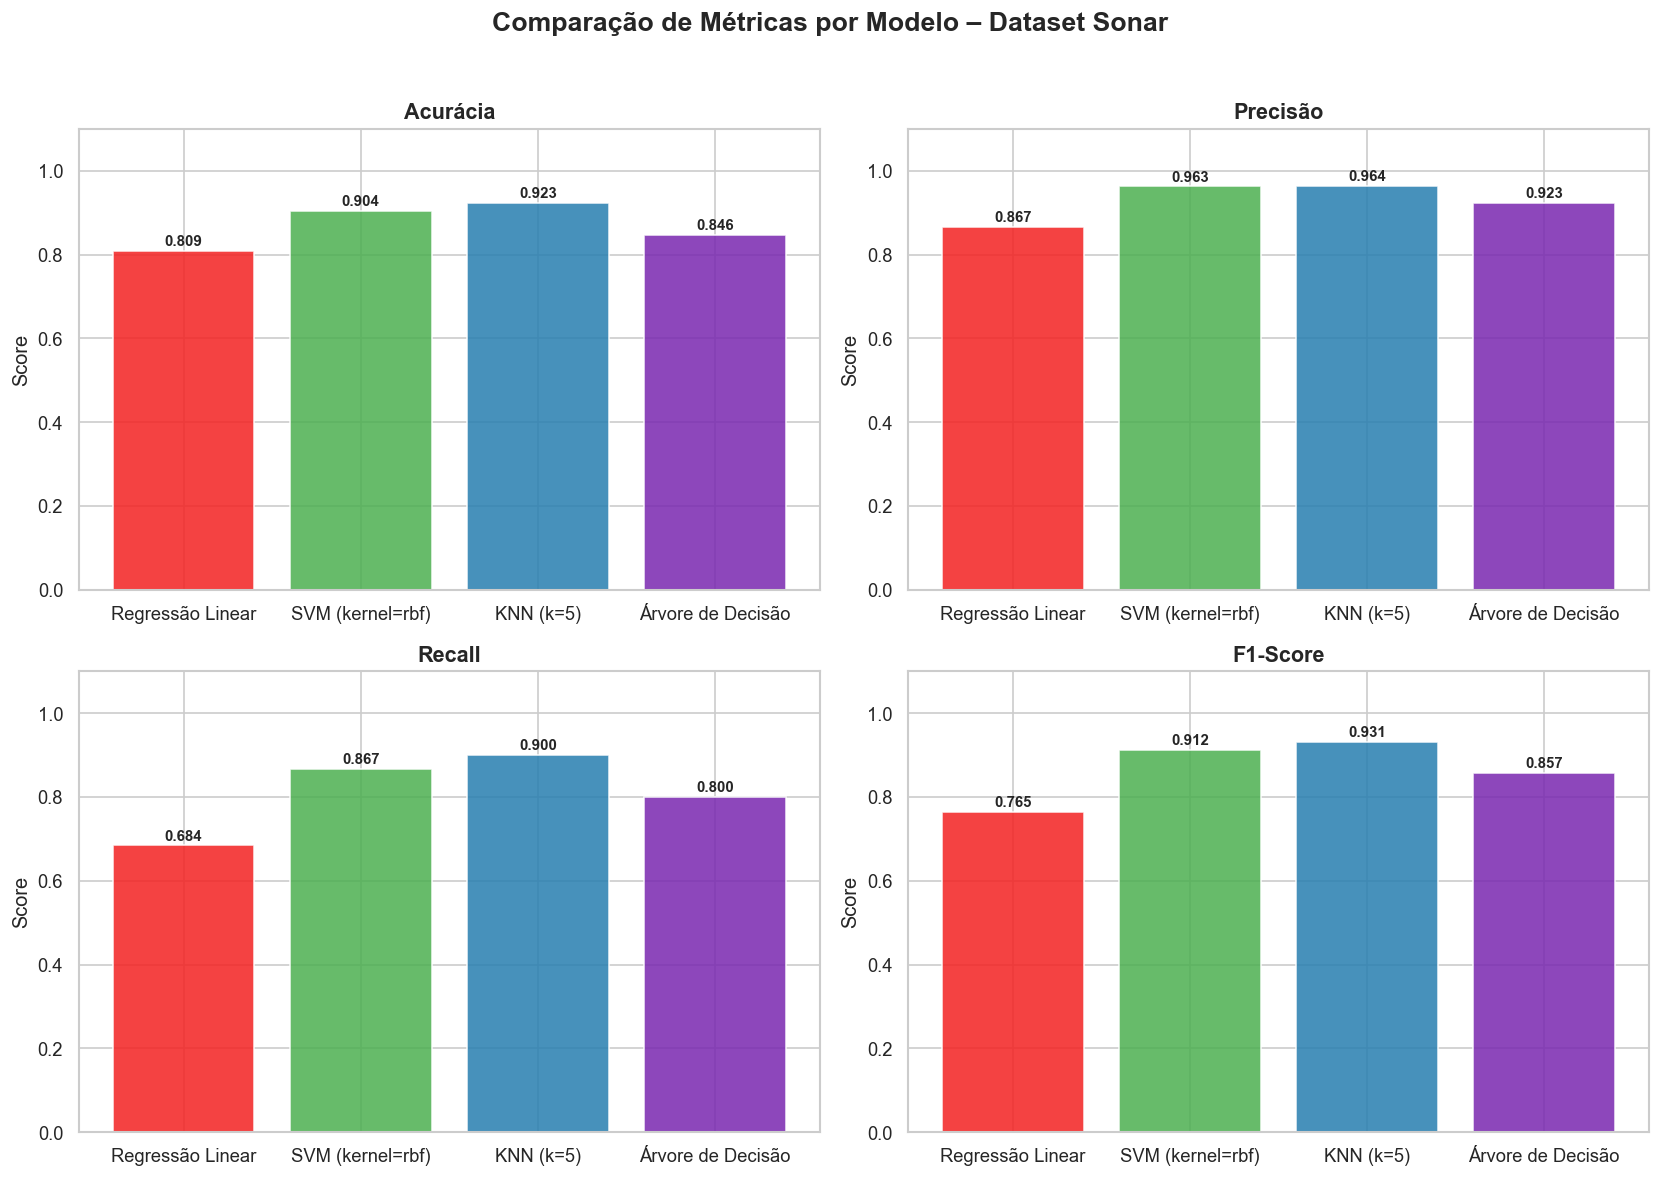

In [3]:
metricas_plot = ["Acurácia", "Precisão", "Recall", "F1-Score"]
modelos = df_comp.index.tolist()
cores = ["#F32121", "#4CAF50", "#277EB0", "#7927B0"]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for idx, metrica in enumerate(metricas_plot):
    ax = axs[idx]

    valores = [df_comp.loc[modelo, metrica] for modelo in modelos]

    bars = ax.bar(
        modelos,
        valores,
        color=cores[:len(modelos)],
        alpha=0.85,
        edgecolor='white'
    )

    # Valores acima das barras
    for bar, val in zip(bars, valores):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')

fig.suptitle(
    'Comparação de Métricas por Modelo – Dataset Sonar',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig('comparativo_metricas_quadrantes.png', bbox_inches='tight')
plt.show()

## 4. Radar Chart (Visão Holística)

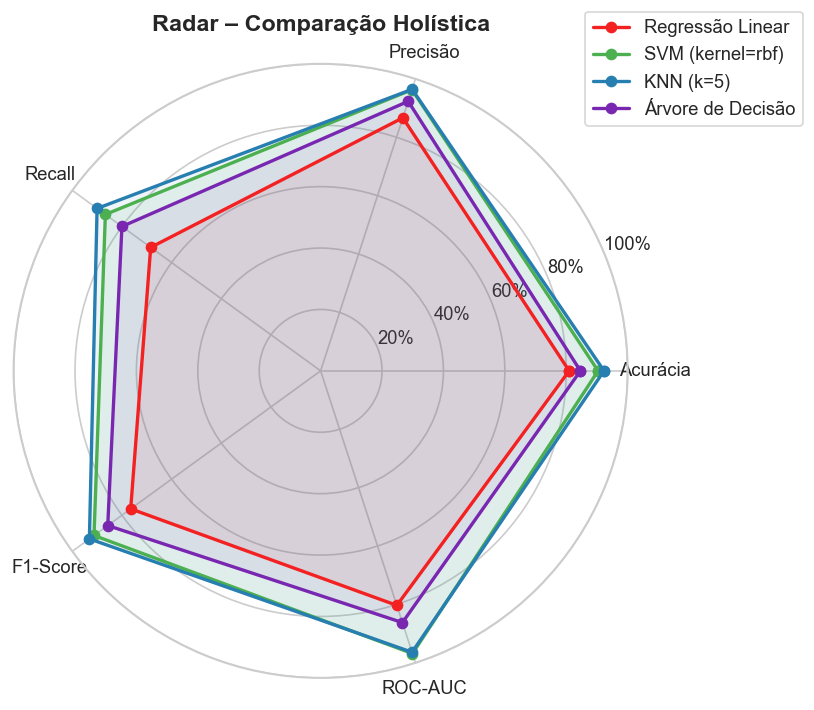

In [4]:
from matplotlib.patches import FancyArrowPatch

cats   = ["Acurácia", "Precisão", "Recall", "F1-Score", "ROC-AUC"]
N      = len(cats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
cores =  ["#F32121", "#4CAF50", "#277EB0", "#7927B0"]

for modelo, cor in zip(modelos, cores):
    vals = [df_comp.loc[modelo, c] for c in cats]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2, color=cor, label=modelo)
    ax.fill(angles, vals, alpha=0.08, color=cor)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats, fontsize=11)
ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Radar – Comparação Holística', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('radar_comparativo.png', bbox_inches='tight')
plt.show()


## 5. Análise de Contexto: Recall e FN

In [5]:
print("""
╔════════════════════════════════════════════════════════════╗
║          ANÁLISE DE CONTEXTO — DETECÇÃO DE MINAS           ║
╠════════════════════════════════════════════════════════════╣
║  Neste problema, um FALSO NEGATIVO (mina classificada como ║
║  rocha) é crítico — pode resultar em risco de vida.        ║
║                                                            ║
║  Portanto, além da Acurácia, o RECALL (Sensibilidade)      ║
║  é a métrica mais relevante para o contexto operacional.   ║
║                                                            ║
║  Um modelo com Recall alto sacrifica menos minas reais.    ║
╚════════════════════════════════════════════════════════════╝
""")

melhor_recall = df_comp["Recall"].idxmax()
melhor_f1     = df_comp["F1-Score"].idxmax()
melhor_acc    = df_comp["Acurácia"].idxmax()

print(f"Melhor Recall   : {melhor_recall}  ({df_comp.loc[melhor_recall, 'Recall']:.4f})")
print(f"Melhor F1-Score : {melhor_f1}     ({df_comp.loc[melhor_f1, 'F1-Score']:.4f})")
print(f"Melhor Acurácia : {melhor_acc}    ({df_comp.loc[melhor_acc, 'Acurácia']:.4f})")



╔════════════════════════════════════════════════════════════╗
║          ANÁLISE DE CONTEXTO — DETECÇÃO DE MINAS           ║
╠════════════════════════════════════════════════════════════╣
║  Neste problema, um FALSO NEGATIVO (mina classificada como ║
║  rocha) é crítico — pode resultar em risco de vida.        ║
║                                                            ║
║  Portanto, além da Acurácia, o RECALL (Sensibilidade)      ║
║  é a métrica mais relevante para o contexto operacional.   ║
║                                                            ║
║  Um modelo com Recall alto sacrifica menos minas reais.    ║
╚════════════════════════════════════════════════════════════╝

Melhor Recall   : KNN (k=5)  (0.9000)
Melhor F1-Score : KNN (k=5)     (0.9310)
Melhor Acurácia : KNN (k=5)    (0.9231)


## 6. Ranking Final

In [6]:
df_rank = df_comp.copy()
df_rank["Score Ponderado"] = (
    df_rank["Acurácia"]  * 0.15 +
    df_rank["Precisão"]  * 0.15 +
    df_rank["Recall"]    * 0.30 +
    df_rank["F1-Score"]  * 0.25 +
    df_rank["ROC-AUC"]   * 0.15
)

df_rank = df_rank.sort_values("Score Ponderado", ascending=False)
df_rank["Ranking"] = range(1, len(df_rank)+1)

print("=== RANKING FINAL (ponderado pelo contexto) ===")
display(df_rank[["Ranking","Acurácia","Recall","F1-Score","Score Ponderado"]].style.format("{:.4f}"))

print(f"Justificativa: melhor equilíbrio entre Recall e F1-Score no contexto de detecção de minas.")


=== RANKING FINAL (ponderado pelo contexto) ===


,Ranking,Acurácia,Recall,F1-Score,Score Ponderado
Modelo,,,,,
KNN (k=5),1.0000,0.9231,0.9000,0.9310,0.9304
SVM (kernel=rbf),2.0000,0.9038,0.8667,0.9123,0.9133
Árvore de Decisão,3.0000,0.8462,0.8000,0.8571,0.8490
Regressão Linear,4.0000,0.8095,0.6842,0.7647,0.7683


Justificativa: melhor equilíbrio entre Recall e F1-Score no contexto de detecção de minas.
